# Laser power noise / RIN vs the thermal-floor requirement

Power noise of the imaging laser from the `RDS-PD_IN1` monitor, in **absolute power
units referred to the chamber**, against the ~1 µW/√Hz goal.

**Where the requirement comes from.** Thermal kicks and laser power fluctuations both
enter the rotor as *torques*, and both are then shaped by the same mechanical response
$1/(I\sqrt{\gamma^2+(2\pi f)^2})$. The response cancels from the comparison, so the
requirement is a torque-vs-torque statement and is **independent of Fourier frequency**:

$$\delta P_{\rm req} \;=\; \frac{\sqrt{4k_BT\gamma I}}{\partial N/\partial P}$$

With τ = 67.65 min, $I = 1.88\times10^{-11}$ kg m², thermal torque noise is
8.76e-18 N m/√Hz, and the torque calibration gives **δP ≈ 0.74 µW/√Hz** — which is what
the round 1 µW/√Hz goal is tracking.

> **Calibration caution.** `laser_stepdown_forward_model.ipynb` quotes κ in **N m per PD
> count**, valid only at the PD gain of that run. The post-tweak record sits at ~2166
> counts for 9.55 mW versus ~16.2 counts/mW before — a ~14x change — so that constant
> must **not** be reused with the new counts. Everything here is converted to physical
> power first, and torque is taken per **mW**, which is gain-independent.

---
### Band coverage

The post-tweak record is **900 s** (two contiguous segments, no gap), reaching down to
1.11 mHz. That covers the upper part of the 0.3-10 mHz requirement band: reliable to
~3-4 mHz with a few averages, and indicative but noisy below that. The bottom of the
band, 0.3-1 mHz, still needs a record of a few hours.

Two spectral estimates are used throughout, since no single segment length serves both
ends: **300 s segments** (3.3 mHz resolution, ~5 averages) for the low-frequency band,
and **16 s segments** (0.06 Hz resolution, ~110 averages) for everything above ~0.2 Hz.

Raw standard deviations are not comparable between records of different length;
everything below is band-limited ASD.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from scipy.signal import welch, find_peaks
from scipy.ndimage import median_filter

DATA = ('/Users/dcmoore/Yale University Dropbox/David Moore/shared_drives/'
        'Microspheres/TFINER/data')
PD_NEW = f'{DATA}/PD/Y1_RDS-PD_IN1_DQ_1468961075_1468961975.h5'   # post-tweak, 900 s
PD_OLD = f'{DATA}/PD/Y1_RDS-PD_IN1_DQ_1467323190_1467582390.h5'   # step-down run

GPS_UNIX_OFFSET = 315964800 - 18
def gps_to_dt(g):
    return datetime.fromtimestamp(g + GPS_UNIX_OFFSET, tz=timezone.utc)

# -- measured operating point -------------------------------------------------------
P_CHAMBER_MW = 9.55          # mW at the chamber, measured, for the post-tweak record
TARGET_UW    = 1.0           # uW/sqrt(Hz) -- the working goal

# -- rotor / thermal constants ------------------------------------------------------
KB_J, T_BATH = 1.380649e-23, 300.0
I_KGM2     = 1.88e-11
TAU_FREE_S = 67.65 * 60.0
GAMMA      = 1.0 / TAU_FREE_S
S_N_THERMAL = np.sqrt(4 * KB_J * T_BATH * GAMMA * I_KGM2)      # N m / sqrt(Hz)

# Torque per unit POWER (gain-independent), from the pre-tweak calibration:
#   kappa = 7.3499e-16 N m per PD count at 16.21 counts/mW
KAPPA_PD_OLD    = 7.3499e-16
CTS_PER_MW_OLD  = 167.6 / 10.34
TORQUE_PER_MW   = KAPPA_PD_OLD * CTS_PER_MW_OLD                # N m per mW

REQ_UW = S_N_THERMAL / TORQUE_PER_MW * 1e3                     # uW / sqrt(Hz)

print(f'thermal torque noise  = {S_N_THERMAL:.3e} N m/sqrt(Hz)')
print(f'torque per mW         = {TORQUE_PER_MW:.3e} N m/mW')
print(f'REQUIREMENT           = {REQ_UW:.3f} uW/sqrt(Hz)   (frequency-independent)')
print(f'working goal          = {TARGET_UW:.3f} uW/sqrt(Hz)')
print(f'  -> as RIN at {P_CHAMBER_MW} mW: {REQ_UW*1e-3/P_CHAMBER_MW:.2e} /sqrt(Hz) '
      f'= {10*np.log10((REQ_UW*1e-3/P_CHAMBER_MW)**2):.1f} dBc/Hz')

thermal torque noise  = 8.760e-18 N m/sqrt(Hz)
torque per mW         = 1.191e-14 N m/mW
REQUIREMENT           = 0.735 uW/sqrt(Hz)   (frequency-independent)
working goal          = 1.000 uW/sqrt(Hz)
  -> as RIN at 9.55 mW: 7.70e-05 /sqrt(Hz) = -82.3 dBc/Hz


## 1. Load and calibrate

In [2]:
def load_h5(path, gps_t0=None, gps_t1=None, stride=1):
    # Segment-aware read. Returns (t_gps, y_counts, fs_effective).
    ts, ys = [], []
    with h5py.File(path, 'r') as f:
        fs = float(f.attrs['sample_rate'])
        for g0, ix, n in zip(f['segments/gps_start'][:].astype(np.float64),
                             f['segments/index_start'][:].astype(np.int64),
                             f['segments/length'][:].astype(np.int64)):
            if gps_t0 is not None and (g0 + n / fs < gps_t0 or g0 > gps_t1):
                continue
            y = f['data'][ix:ix + n:stride].astype(np.float64)
            t = g0 + np.arange(len(y)) * stride / fs
            if gps_t0 is not None:
                k = (t >= gps_t0) & (t <= gps_t1)
                t, y = t[k], y[k]
            ts.append(t); ys.append(y)
    t = np.concatenate(ts); y = np.concatenate(ys)
    o = np.argsort(t)
    return t[o], y[o], fs / stride


t_new, y_new, fs_new = load_h5(PD_NEW)
dur_new = len(y_new) / fs_new
pd_new  = np.median(y_new)
CTS_PER_MW_NEW = pd_new / P_CHAMBER_MW

print(f'file      : {PD_NEW.split("/")[-1]}')
print(f'start UTC : {gps_to_dt(t_new[0]):%Y-%m-%d %H:%M:%S}')
print(f'duration  : {dur_new:.0f} s at {fs_new:.0f} Hz ({len(y_new):,} samples)')
print(f'level     : {pd_new:.1f} counts = {P_CHAMBER_MW} mW '
      f'-> {CTS_PER_MW_NEW:.1f} counts/mW')
print(f'            (pre-tweak was {CTS_PER_MW_OLD:.1f} counts/mW, '
      f'a factor {CTS_PER_MW_NEW/CTS_PER_MW_OLD:.1f} change)')
print(f'\nrecord length {dur_new:.0f} s -> lowest Fourier frequency '
      f'{1e3/dur_new:.2f} mHz')
print('reaches the TOP of the 0.3-10 mHz requirement band; the bottom (<3 mHz)')
print('still needs a run of a few hours')


def to_uW(psd_counts, cts_per_mW):
    # PSD in counts^2/Hz -> amplitude spectral density in uW/sqrt(Hz)
    return np.sqrt(psd_counts) / cts_per_mW * 1e3

file      : Y1_RDS-PD_IN1_DQ_1468961075_1468961975.h5
start UTC : 2026-07-24 20:44:17
duration  : 900 s at 1024 Hz (921,600 samples)
level     : 2177.4 counts = 9.55 mW -> 228.0 counts/mW
            (pre-tweak was 16.2 counts/mW, a factor 14.1 change)

record length 900 s -> lowest Fourier frequency 1.11 mHz
reaches the TOP of the 0.3-10 mHz requirement band; the bottom (<3 mHz)
still needs a run of a few hours


## 2. Time series

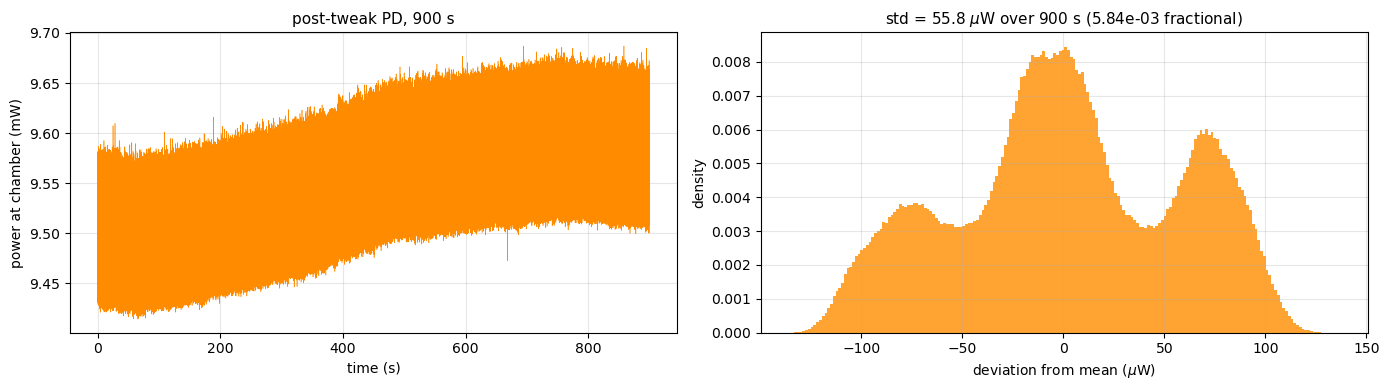

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(t_new - t_new[0], y_new / CTS_PER_MW_NEW, lw=0.4, color='darkorange')
axes[0].set_xlabel('time (s)'); axes[0].set_ylabel('power at chamber (mW)')
axes[0].set_title(f'post-tweak PD, {dur_new:.0f} s', fontsize=11)
axes[0].grid(True, alpha=0.3)

dev_uW = (y_new / CTS_PER_MW_NEW - P_CHAMBER_MW) * 1e3
axes[1].hist(dev_uW, bins=200, color='darkorange', alpha=0.8, density=True)
axes[1].set_xlabel('deviation from mean ($\\mu$W)'); axes[1].set_ylabel('density')
axes[1].set_title(f'std = {dev_uW.std():.1f} $\\mu$W over {dur_new:.0f} s '
                  f'({y_new.std()/pd_new:.2e} fractional)', fontsize=11)
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Power-noise spectrum vs the requirement

16 s Welch segments: 0.0625 Hz resolution, ~6 averages out of the 60 s.

low-f estimate: 3.33 mHz resolution, trust above ~10.0 mHz


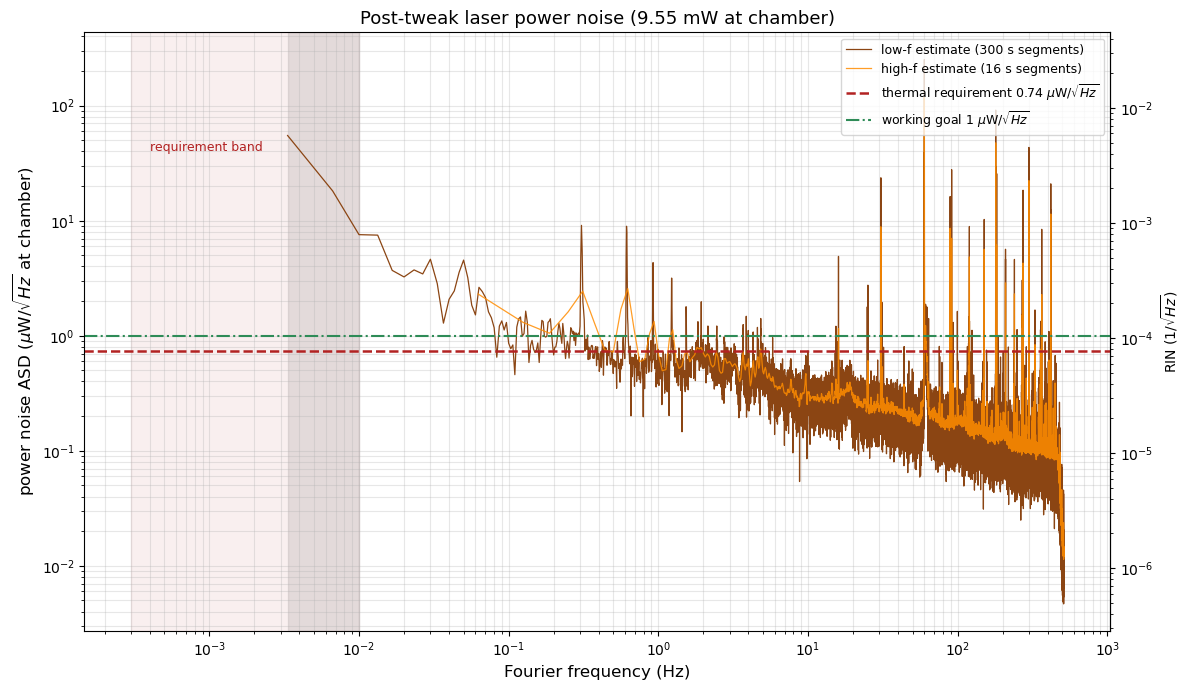

Broadband level by band (median, excludes lines):
        band (Hz) |   uW/rtHz |   vs req | peak in band
--------------------------------------------------------
  0.003 -   0.010 |   36.5965 |   49.77x |       55.05  <-- too few averages, indicative only
  0.010 -   0.100 |    2.2862 |    3.11x |        7.49
  0.100 -   0.500 |    0.8208 |    1.12x |        9.11
  0.500 -   2.000 |    0.7005 |    0.95x |        2.57
  2.000 -  10.000 |    0.3999 |    0.54x |        0.77
 10.000 -  50.000 |    0.2430 |    0.33x |        8.85
 50.000 - 200.000 |    0.1640 |    0.22x |      117.36
200.000 - 500.000 |    0.1056 |    0.14x |       22.30


In [4]:
NPERSEG    = 16384                      # 16 s  -> high-frequency estimate
NPERSEG_LO = int(300 * fs_new)          # 300 s -> low-frequency estimate

# linear detrend before the low-frequency estimate: 15 min of drift would otherwise
# leak across the whole band
y_det = y_new - np.polyval(np.polyfit(t_new - t_new[0], y_new, 1), t_new - t_new[0])

f_new, P_new = welch(y_new - y_new.mean(), fs=fs_new, nperseg=NPERSEG)
uw_new = to_uW(P_new, CTS_PER_MW_NEW)

f_lo, P_lo = welch(y_det, fs=fs_new, nperseg=NPERSEG_LO)
uw_lo = to_uW(P_lo, CTS_PER_MW_NEW)

f_ok    = 2.0 / (NPERSEG / fs_new)
f_ok_lo = 3.0 / (NPERSEG_LO / fs_new)   # ~3 bins down before averaging gets thin
print(f'low-f estimate: {fs_new/NPERSEG_LO*1e3:.2f} mHz resolution, '
      f'trust above ~{f_ok_lo*1e3:.1f} mHz')

fig, ax = plt.subplots(figsize=(12, 7))
ax.loglog(f_lo[1:], uw_lo[1:], lw=0.9, color='saddlebrown',
          label=f'low-f estimate ({NPERSEG_LO/fs_new:.0f} s segments)')
ax.loglog(f_new[1:], uw_new[1:], lw=0.9, color='darkorange', alpha=0.85,
          label=f'high-f estimate ({NPERSEG/fs_new:.0f} s segments)')
ax.axhline(REQ_UW, color='firebrick', ls='--', lw=1.8,
           label=f'thermal requirement {REQ_UW:.2f} $\\mu$W/$\\sqrt{{Hz}}$')
ax.axhline(TARGET_UW, color='seagreen', ls='-.', lw=1.5,
           label=f'working goal {TARGET_UW:.0f} $\\mu$W/$\\sqrt{{Hz}}$')
ax.axvspan(3e-4, 1e-2, color='firebrick', alpha=0.07)
ax.text(4e-4, 4e1, 'requirement band', fontsize=9, color='firebrick')
ax.axvspan(f_lo[1], f_ok_lo, color='gray', alpha=0.18)
ax.set_xlabel('Fourier frequency (Hz)', fontsize=12)
ax.set_ylabel('power noise ASD ($\\mu$W/$\\sqrt{Hz}$ at chamber)', fontsize=12)
ax.set_title(f'Post-tweak laser power noise ({P_CHAMBER_MW} mW at chamber)', fontsize=13)
sec = ax.secondary_yaxis('right',
                         functions=(lambda x: x * 1e-3 / P_CHAMBER_MW,
                                    lambda r: r * P_CHAMBER_MW * 1e3))
sec.set_ylabel('RIN (1/$\\sqrt{Hz}$)', fontsize=10)
ax.legend(fontsize=9, loc='upper right'); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

print('Broadband level by band (median, excludes lines):')
print(f"{'band (Hz)':>17} | {'uW/rtHz':>9} | {'vs req':>8} | {'peak in band':>11}")
print('-' * 56)
for lo, hi, src in [(0.003, 0.01, 'lo'), (0.01, 0.1, 'lo'), (0.1, 0.5, 'lo'),
                    (0.5, 2, 'hi'), (2, 10, 'hi'), (10, 50, 'hi'),
                    (50, 200, 'hi'), (200, 500, 'hi')]:
    ff, uu = (f_lo, uw_lo) if src == 'lo' else (f_new, uw_new)
    b = (ff > lo) & (ff < hi)
    med = np.median(uu[b])
    flag = '  <-- too few averages, indicative only' if hi <= f_ok_lo else ''
    print(f'{lo:7.3f} - {hi:7.3f} | {med:9.4f} | {med/REQ_UW:7.2f}x | '
          f'{uu[b].max():11.2f}{flag}')

## 4. Lines

Peaks more than 8x above a running-median baseline. These matter for a servo (they
consume loop gain and dynamic range, and they point at pickup) but note the rotor's own
response falls as $\gamma/2\pi f$ above the corner, so a line at 60 Hz is suppressed by
~$10^{-6}$ before it reaches the spin frequency.

   f (Hz) |    uW/rtHz |  x baseline |    x req
------------------------------------------------
    59.94 |    117.363 |        257x |   159.6x
   179.81 |     47.501 |        344x |    64.6x
   299.69 |     22.304 |        198x |    30.3x
   419.56 |     11.428 |        113x |    15.5x
   419.38 |      9.365 |         93x |    12.7x
    30.69 |      8.854 |         36x |    12.0x
    89.12 |      8.605 |         49x |    11.7x
    91.25 |      7.022 |         40x |     9.5x
   182.50 |      6.151 |         44x |     8.4x
   150.56 |      5.645 |         38x |     7.7x
   119.88 |      4.843 |         27x |     6.6x
   273.75 |      4.284 |         39x |     5.8x


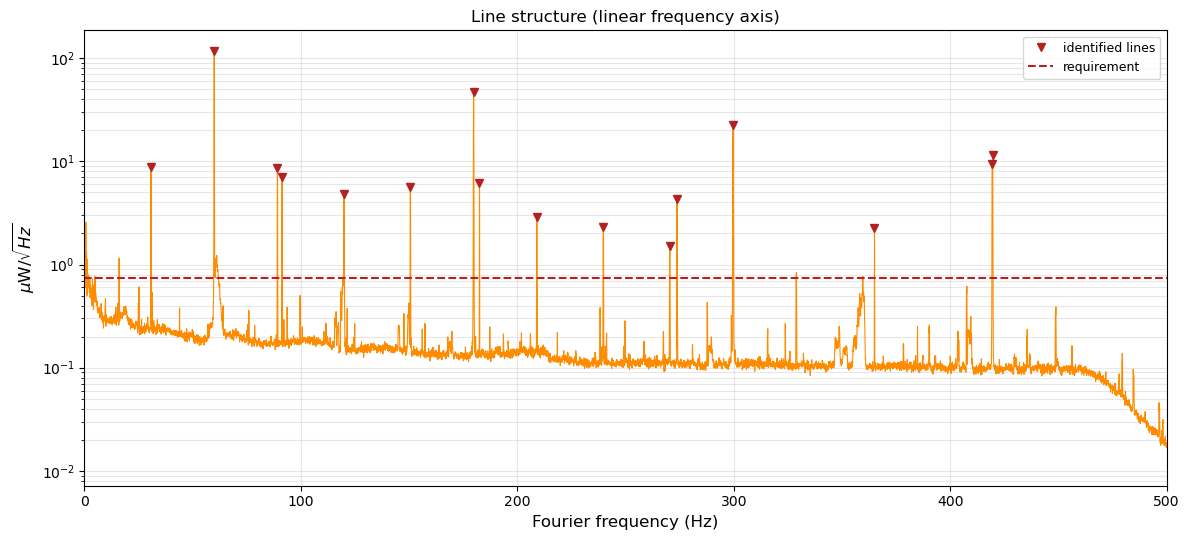

In [5]:
m = f_new > 0.2
fm, um = f_new[m], uw_new[m]
base = median_filter(um, size=101)
pk, _ = find_peaks(um / base, height=8, distance=3)
order = np.argsort(um[pk])[::-1]

print(f"{'f (Hz)':>9} | {'uW/rtHz':>10} | {'x baseline':>11} | {'x req':>8}")
print('-' * 48)
for i in pk[order][:12]:
    print(f'{fm[i]:9.2f} | {um[i]:10.3f} | {um[i]/base[i]:10.0f}x | {um[i]/REQ_UW:7.1f}x')

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.semilogy(f_new[1:], uw_new[1:], lw=0.8, color='darkorange')
ax.semilogy(fm[pk], um[pk], 'v', ms=6, color='firebrick', label='identified lines')
ax.axhline(REQ_UW, color='firebrick', ls='--', lw=1.5, label='requirement')
ax.set_xlim(0, 500)
ax.set_xlabel('Fourier frequency (Hz)', fontsize=12)
ax.set_ylabel('$\\mu$W/$\\sqrt{Hz}$', fontsize=12)
ax.set_title('Line structure (linear frequency axis)', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Before vs after the tweak

Matched 60 s chunk from the middle of the settled step-3 plateau, processed identically,
plus the full 16 h at 1 Hz to show the band this new record does not yet reach.

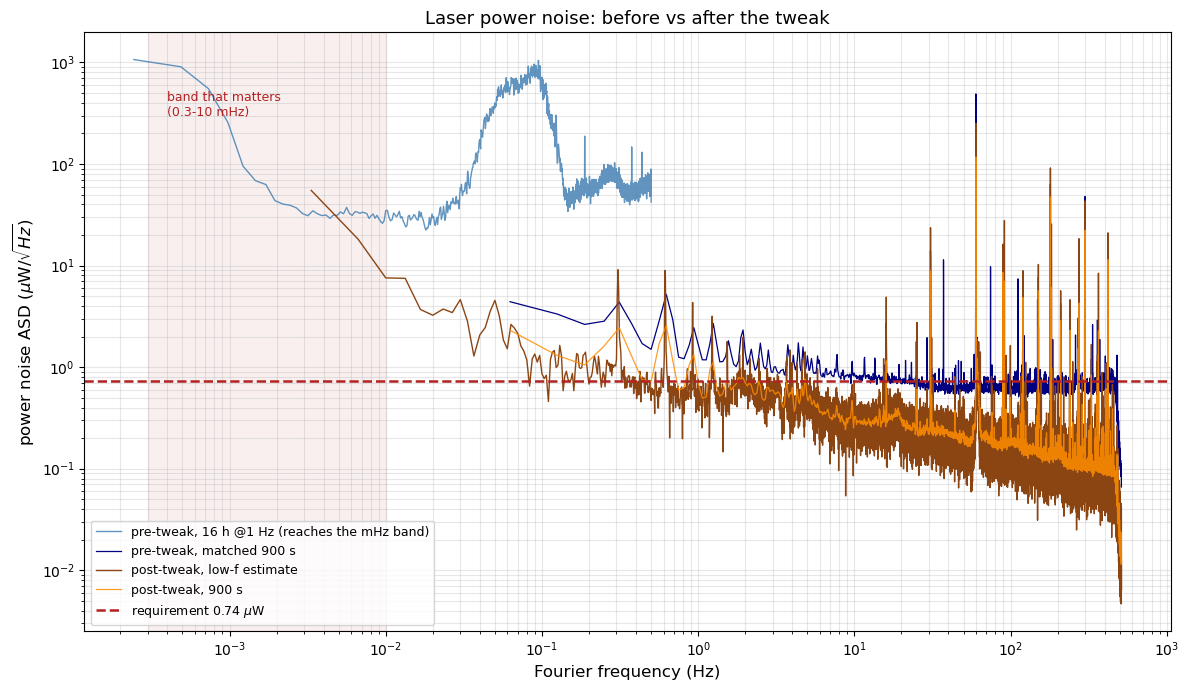

(below 0.05 Hz the pre-tweak column is the 16 h record, the only one covering it)
  f (Hz) |        pre |       post |  improve |  post/req
--------------------------------------------------------
   0.003 |     32.123 |    52.7500 |     0.6x |    71.74x (few averages)
   0.005 |     32.465 |    40.9845 |     0.8x |    55.74x (few averages)
   0.010 |     34.637 |     7.5645 |     4.6x |    10.29x
   0.030 |     57.396 |     4.6228 |    12.4x |     6.29x
   0.100 |      3.801 |     1.7745 |     2.1x |     2.41x
   0.300 |      4.108 |     2.2984 |     1.8x |     3.13x
   1.000 |      1.676 |     0.7005 |     2.4x |     0.95x
   3.000 |      0.886 |     0.5959 |     1.5x |     0.81x
  10.000 |      0.854 |     0.3261 |     2.6x |     0.44x
  30.000 |      0.724 |     0.2325 |     3.1x |     0.32x
 100.000 |      0.610 |     0.1858 |     3.3x |     0.25x
 300.000 |      0.691 |     0.2192 |     3.2x |     0.30x


In [6]:
T0_OLD = 1467406290 + 3 * TAU_FREE_S + 8 * 3600
t_o60, y_o60, fs_o60 = load_h5(PD_OLD, T0_OLD, T0_OLD + dur_new)   # matched length
f_o60, P_o60 = welch(y_o60 - y_o60.mean(), fs=fs_o60, nperseg=NPERSEG)
uw_o60 = to_uW(P_o60, CTS_PER_MW_OLD)

t_ol, y_ol, fs_ol = load_h5(PD_OLD, 1467406290 + 3 * TAU_FREE_S, 1467477690 - 300,
                            stride=1024)
y_ol_d = y_ol - np.polyval(np.polyfit(t_ol - t_ol[0], y_ol, 1), t_ol - t_ol[0])
f_ol, P_ol = welch(y_ol_d, fs=fs_ol, nperseg=4096)
uw_ol = to_uW(P_ol, CTS_PER_MW_OLD)

fig, ax = plt.subplots(figsize=(12, 7))
ax.loglog(f_ol[1:], uw_ol[1:], lw=1.0, color='steelblue', alpha=0.85,
          label='pre-tweak, 16 h @1 Hz (reaches the mHz band)')
ax.loglog(f_o60[1:], uw_o60[1:], lw=0.9, color='navy',
          label=f'pre-tweak, matched {dur_new:.0f} s')
ax.loglog(f_lo[1:], uw_lo[1:], lw=1.0, color='saddlebrown',
          label='post-tweak, low-f estimate')
ax.loglog(f_new[1:], uw_new[1:], lw=0.9, color='darkorange', alpha=0.85,
          label=f'post-tweak, {dur_new:.0f} s')
ax.axhline(REQ_UW, color='firebrick', ls='--', lw=1.8, label='requirement 0.74 $\\mu$W')
ax.axvspan(3e-4, 1e-2, color='firebrick', alpha=0.07)
ax.text(4e-4, 3e2, 'band that matters\n(0.3-10 mHz)', fontsize=9, color='firebrick')
ax.set_xlabel('Fourier frequency (Hz)', fontsize=12)
ax.set_ylabel('power noise ASD ($\\mu$W/$\\sqrt{Hz}$)', fontsize=12)
ax.set_title('Laser power noise: before vs after the tweak', fontsize=13)
ax.legend(fontsize=9, loc='lower left'); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

print('(below 0.05 Hz the pre-tweak column is the 16 h record, the only one covering it)')
print(f"{'f (Hz)':>8} | {'pre':>10} | {'post':>10} | {'improve':>8} | {'post/req':>9}")
print('-' * 56)
for f0 in [0.003, 0.005, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300]:
    mark = ' (few averages)' if f0 < f_ok_lo else ''
    # pre-tweak: the 16 h record is the only thing covering the mHz band
    if f0 < 0.05:
        a = to_uW(np.interp(f0, f_ol, P_ol), CTS_PER_MW_OLD)
        b = to_uW(np.interp(f0, f_lo, P_lo), CTS_PER_MW_NEW)
    else:
        a = to_uW(np.interp(f0, f_o60, P_o60), CTS_PER_MW_OLD)
        b = to_uW(np.interp(f0, f_new, P_new), CTS_PER_MW_NEW)
    print(f'{f0:8.3f} | {a:10.3f} | {b:10.4f} | {a/b:7.1f}x | {b/REQ_UW:8.2f}x{mark}')

## 6. Shot noise — how much headroom is left?

The optical power on the diode is not recorded, so rather than assume it, invert:
**what power would make the observed floor shot-noise limited?** If the diode sees much
more than that, the floor is technical and there is room to improve.

In [7]:
E_CHARGE, RESPONSIVITY = 1.602176634e-19, 0.7   # A/W; adjust to the actual diode

def shot_rin(P_watt):
    return np.sqrt(2 * E_CHARGE / (RESPONSIVITY * P_watt))

def power_for_rin(rin):
    return 2 * E_CHARGE / (RESPONSIVITY * rin ** 2)

hf = (f_new > 100) & (f_new < 400)
floor_uW  = np.median(uw_new[hf])
floor_rin = floor_uW * 1e-3 / P_CHAMBER_MW

print(f'post-tweak floor (100-400 Hz): {floor_uW:.4f} uW/sqrt(Hz) '
      f'= {floor_rin:.2e} /sqrt(Hz)')
print(f'  shot-noise limited only if the diode saw only '
      f'{power_for_rin(floor_rin)*1e9:.2f} nW')
print(f'  if the diode sees 1 mW, shot noise would be '
      f'{shot_rin(1e-3)*P_CHAMBER_MW*1e3:.5f} uW/sqrt(Hz) '
      f'-- {floor_rin/shot_rin(1e-3):.0f}x below the observed floor')
req_rin = REQ_UW * 1e-3 / P_CHAMBER_MW
print(f'\npower needed for shot noise alone to meet {REQ_UW:.2f} uW/sqrt(Hz): '
      f'{power_for_rin(req_rin)*1e12:.0f} pW')
print('photon statistics are orders of magnitude from limiting -- any floor above'
      '\nthat is an implementation issue, not a fundamental one.')

post-tweak floor (100-400 Hz): 0.1199 uW/sqrt(Hz) = 1.26e-05 /sqrt(Hz)
  shot-noise limited only if the diode saw only 2.91 nW
  if the diode sees 1 mW, shot noise would be 0.00020 uW/sqrt(Hz) -- 587x below the observed floor

power needed for shot noise alone to meet 0.74 uW/sqrt(Hz): 77 pW
photon statistics are orders of magnitude from limiting -- any floor above
that is an implementation issue, not a fundamental one.


## 7. Where this leaves us

Read the numbers above, but the structure of the answer:

- **Broadband floor:** compare the 100–400 Hz median to the 0.74 µW/√Hz requirement.
- **Low-frequency end of this record (0.1–0.5 Hz):** the closest this file gets to the
  band that matters, and the place to watch.
- **Lines:** irrelevant to the rotor (suppressed by $\gamma/2\pi f$) but they indicate
  pickup and would cost a servo dynamic range.
- **Now partly measured:** the 900 s record is trustworthy down to ~10 mHz (≈5 averages
  at 3.3 mHz resolution). Between 3 and 10 mHz it is indicative only — one to two
  effective averages — and below 3 mHz it says nothing. A few hours at a fixed setpoint
  is still the measurement that closes this out.

An independent cross-check worth doing once such a record exists: the rotor is itself a
torque-integrating power monitor, and below ~1 mHz it was *quieter* than the pre-tweak
PD — so it sets an upper limit on true RIN that any new detector can be validated
against, without trusting the PD's own drift.